In [1]:
"""
Imports and Configuration for Crossover Filtering
"""
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. CONFIGURE YOUR PATHS (Point to your exported Step 5 Excel directory)
# Edit me!
SUBJECT_NAME = 'ncbc_s18'
TRIAL_NAME = 'p3'

RESULTS_DIR = f'results/{SUBJECT_NAME}/{TRIAL_NAME}'

REF_L_PATH = os.path.join(RESULTS_DIR, 'reference_waveforms_L.xlsx')
REF_R_PATH = os.path.join(RESULTS_DIR, 'reference_waveforms_R.xlsx')
PRED_L_PATH = os.path.join(RESULTS_DIR, 'pred_wavevforms_L.xlsx')
PRED_R_PATH = os.path.join(RESULTS_DIR, 'pred_waveforms_R.xlsx')

# Load the stride dataframes
ref_L = pd.read_excel(REF_L_PATH)
ref_R = pd.read_excel(REF_R_PATH)
pred_L = pd.read_excel(PRED_L_PATH)
pred_R = pd.read_excel(PRED_R_PATH)

# Convert columns to lists of names for tracking indices
left_stride_names = list(ref_L.columns)
right_stride_names = list(ref_R.columns)

# 2. STITCH STRIDES TO CREATE A CONTINUOUS TIMEROW
def build_continuous_signal(df):
    """Flattens columns back-to-back and tracks where each stride starts"""
    signal = []
    boundaries = []
    current_idx = 0
    for col in df.columns:
        signal.extend(df[col].values)
        boundaries.append(current_idx)
        current_idx += len(df[col])
    return np.array(signal), boundaries

left_signal, left_bounds = build_continuous_signal(ref_L)
right_signal, right_bounds = build_continuous_signal(ref_R)


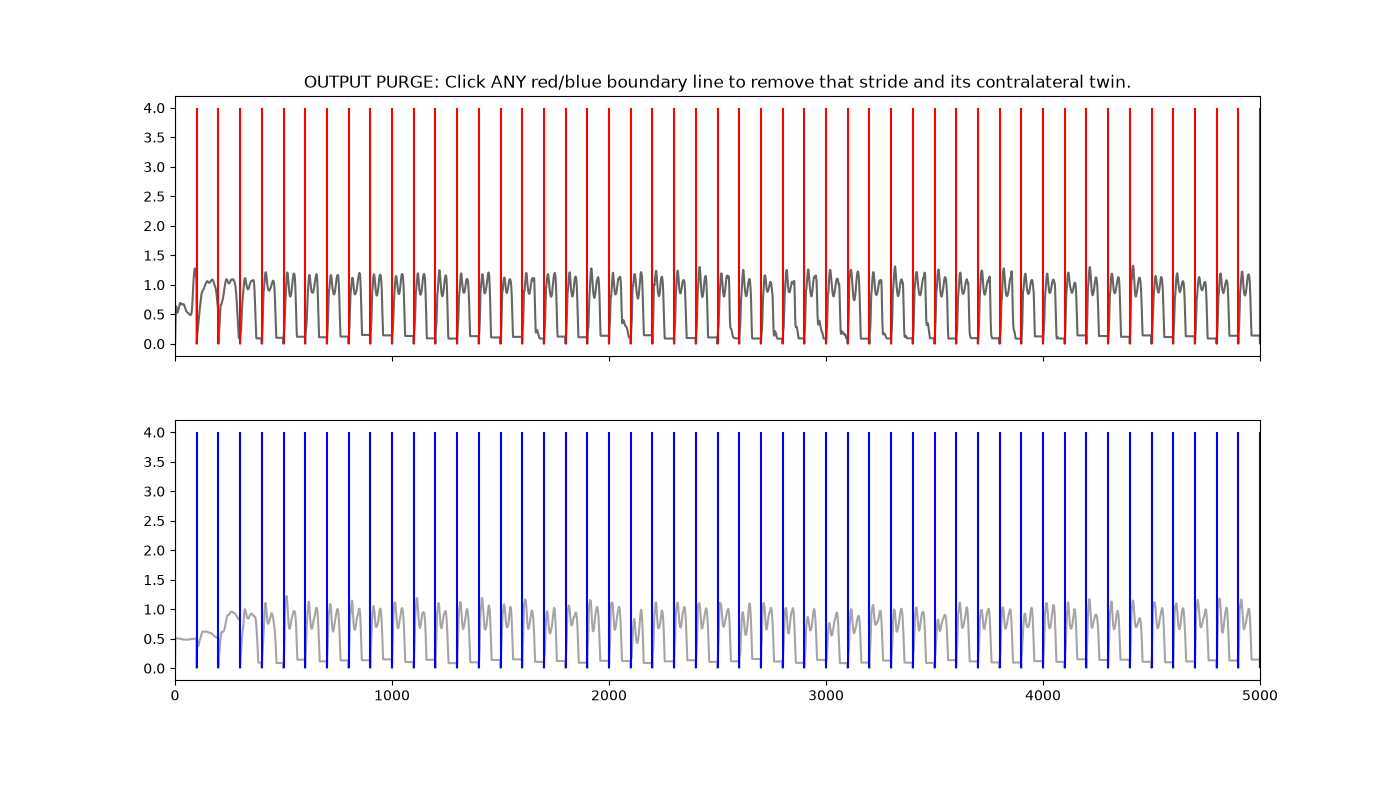

In [2]:
"""
Interactive Crossover Filtering Tool
"""
# Re-enable the Jupyter Notebook Magic Command for pop-up windows!
%matplotlib widget

# Reset tracking sets every time you open the viewer
LEFT_DROPS = set()
RIGHT_DROPS = set()

# 3. SET UP THE INTERACTIVE SUBPLOTS
fig, (ax_L, ax_R) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
plt.subplots_adjust(bottom=0.15, hspace=0.25)

ax_L.plot(left_signal, color='black', alpha=0.6, label='Left Sequential Stances')
ax_R.plot(right_signal, color='dimgray', alpha=0.6, label='Right Sequential Stances')

# Draw click-interactive vertical boundary markers for each stride
left_lines = {}
for idx, frame in enumerate(left_bounds):
    line = ax_L.vlines(frame, 0, 4, color='red', linestyle='-', linewidth=1.5, picker=5)
    left_lines[frame] = {'col_name': left_stride_names[idx], 'line_obj': line, 'side': 'left', 'opp_bounds': right_bounds}

right_lines = {}
for idx, frame in enumerate(right_bounds):
    line = ax_R.vlines(frame, 0, 4, color='blue', linestyle='-', linewidth=1.5, picker=5)
    right_lines[frame] = {'col_name': right_stride_names[idx], 'line_obj': line, 'side': 'right', 'opp_bounds': left_bounds}

ax_L.set_title("OUTPUT PURGE: Click ANY red/blue boundary line to remove that stride and its contralateral twin.")
ax_L.set_xlim(0, 5000) 

def on_pick(event):
    clicked_artist = event.artist
    target, clicked_frame = None, None

    for frame, info in left_lines.items():
        if info['line_obj'] == clicked_artist:
            target, clicked_frame = info, frame
            break
    if not target:
        for frame, info in right_lines.items():
            if info['line_obj'] == clicked_artist:
                target, clicked_frame = info, frame
                break

    if not target: return

    opp_frames = np.array(target['opp_bounds'])
    closest_opp_frame = opp_frames[np.argmin(np.abs(opp_frames - clicked_frame))]

    if target['side'] == 'left':
        l_col = target['col_name']
        r_col = right_lines[closest_opp_frame]['col_name']
        if l_col in LEFT_DROPS:
            LEFT_DROPS.remove(l_col)
            RIGHT_DROPS.remove(r_col)
            target['line_obj'].set(color='red', linestyle='-', linewidth=1.5)
            right_lines[closest_opp_frame]['line_obj'].set(color='blue', linestyle='-', linewidth=1.5)
        else:
            LEFT_DROPS.add(l_col)
            RIGHT_DROPS.add(r_col)
            target['line_obj'].set(color='gold', linestyle='--', linewidth=3.0)
            right_lines[closest_opp_frame]['line_obj'].set(color='gold', linestyle='--', linewidth=3.0)
    else:
        r_col = target['col_name']
        l_col = left_lines[closest_opp_frame]['col_name']
        if r_col in RIGHT_DROPS:
            RIGHT_DROPS.remove(r_col)
            LEFT_DROPS.remove(l_col)
            target['line_obj'].set(color='blue', linestyle='-', linewidth=1.5)
            left_lines[closest_opp_frame]['line_obj'].set(color='red', linestyle='-', linewidth=1.5)
        else:
            RIGHT_DROPS.add(r_col)
            LEFT_DROPS.add(l_col)
            target['line_obj'].set(color='gold', linestyle='--', linewidth=3.0)
            left_lines[closest_opp_frame]['line_obj'].set(color='gold', linestyle='--', linewidth=3.0)

    fig.canvas.draw_idle()

fig.canvas.mpl_connect('pick_event', on_pick)
plt.show()

In [3]:
"""
Save Crossover Files in CSV
"""
import csv

# 1. Map the internal column indices back to your actual stride numbers/names
flagged_left_strides = sorted(list(LEFT_DROPS))
flagged_right_strides = sorted(list(RIGHT_DROPS))

# 2. Build paths for the audit logs
log_path_L = os.path.join(RESULTS_DIR, 'flagged_crossovers_L.csv')
log_path_R = os.path.join(RESULTS_DIR, 'flagged_crossovers_R.csv')

# 3. Write the Left Side CSV Log
with open(log_path_L, mode='w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['stride_name']) # Column header
    for stride in flagged_left_strides:
        writer.writerow([stride])

# 4. Write the Right Side CSV Log
with open(log_path_R, mode='w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['stride_name']) # Column header
    for stride in flagged_right_strides:
        writer.writerow([stride])

print("--- AUDIT LOG GENERATED ---")
print(f"Flagged Left Stride Names ({len(flagged_left_strides)}):  {flagged_left_strides}")
print(f"Flagged Right Stride Names ({len(flagged_right_strides)}): {flagged_right_strides}")
print(f"\nLogs saved to:\n -> {log_path_L}\n -> {log_path_R}")
print("\n[Optional] You can now open these CSV files to verify, or proceed to Cell 4 to delete them.")

--- AUDIT LOG GENERATED ---
Flagged Left Stride Names (33):  [0, 1, 2, 3, 16, 20, 27, 28, 29, 30, 31, 32, 33, 34, 35, 94, 95, 117, 118, 121, 122, 127, 128, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139]
Flagged Right Stride Names (33): [0, 1, 2, 3, 16, 20, 27, 28, 29, 30, 31, 32, 33, 34, 35, 94, 95, 117, 118, 121, 122, 127, 128, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139]

Logs saved to:
 -> results/ncbc_s18/p3/flagged_crossovers_L.csv
 -> results/ncbc_s18/p3/flagged_crossovers_R.csv

[Optional] You can now open these CSV files to verify, or proceed to Cell 4 to delete them.


In [4]:
"""
Delete Strides and Overwrite Excel Files 
"""

# =====================================================================
# OPTIONAL: Run this cell ONLY if you want to permanently delete columns
# =====================================================================

print(f"Executing permanent purge... Dropping {len(LEFT_DROPS)} left and {len(RIGHT_DROPS)} right columns.")

# Drop the flagged stride columns from reference and prediction dataframes
ref_L_clean = ref_L.drop(columns=list(LEFT_DROPS), errors='ignore')
pred_L_clean = pred_L.drop(columns=list(LEFT_DROPS), errors='ignore')

ref_R_clean = ref_R.drop(columns=list(RIGHT_DROPS), errors='ignore')
pred_R_clean = pred_R.drop(columns=list(RIGHT_DROPS), errors='ignore')

# Overwrite the original Excel files
ref_L_clean.to_excel(REF_L_PATH, index=False)
pred_L_clean.to_excel(PRED_L_PATH, index=False)
ref_R_clean.to_excel(REF_R_PATH, index=False)
pred_R_clean.to_excel(PRED_R_PATH, index=False)

print("Excel spreadsheets successfully modified and saved!")

Executing permanent purge... Dropping 33 left and 33 right columns.
Excel spreadsheets successfully modified and saved!
